# Chapter 5 — Reading Text Files and Inspecting a Corpus

Chapter 4 treated a Python string as a finite sequence of characters.
This chapter moves that sequence into a local text file and examines it before tokenization.

By the end of this chapter, you will be able to:

- explain the difference between text, encoded bytes, and a corpus;
- write and read a UTF-8 text file without using a machine-specific path;
- inspect corpus boundaries, lines, blank lines, and basic statistics;
- identify fixture-specific metadata and end markers;
- extract main text without destroying its internal paragraph structure; and
- measure how extraction changes the data available to a model.

## Corpus Files and Encodings

A **corpus** is a collection of text used as data.
A corpus may contain one document or many documents.

A text file stores encoded bytes rather than Python characters directly.
An **encoding** defines how text characters are represented as bytes and recovered from those bytes.
We will use UTF-8 because it supports English text and a wide range of other writing systems.

A **file path** identifies a file's location.
Portable notebooks avoid absolute paths tied to one person's computer.

This notebook also avoids network access.
A remote download can fail or change for reasons unrelated to the lesson, while a small known fixture keeps execution reproducible.

## Build a Small Local Fixture

The fixture below resembles a public-domain text file without claiming to be a real corpus.
It contains two metadata lines, two paragraphs, an accented character, and an end marker.
Those features give us useful boundaries and formatting to inspect.

In [1]:
tiny_corpus_text = (
    "TITLE: Tiny Public-Domain-Style Corpus\n"
    "SOURCE: Local notebook fixture\n"
    "\n"
    "The dog ran across the yard.\n"
    "The cat sat near the café window.\n"
    "\n"
    "The dog looked at the cat.\n"
    "The cat looked back.\n"
    "\n"
    "END OF FIXTURE"
)

print(tiny_corpus_text)
print()
print("Technical representation:")
print(repr(tiny_corpus_text))

TITLE: Tiny Public-Domain-Style Corpus
SOURCE: Local notebook fixture

The dog ran across the yard.
The cat sat near the café window.

The dog looked at the cat.
The cat looked back.

END OF FIXTURE

Technical representation:
'TITLE: Tiny Public-Domain-Style Corpus\nSOURCE: Local notebook fixture\n\nThe dog ran across the yard.\nThe cat sat near the café window.\n\nThe dog looked at the cat.\nThe cat looked back.\n\nEND OF FIXTURE'


## Write Text with an Explicit Encoding

The next cell creates a temporary local directory and writes the fixture with UTF-8.
The directory is removed automatically, so running the notebook does not leave corpus files in the project.

The number of UTF-8 bytes is larger than the number of Python characters because `é` requires more than one byte in UTF-8.
This distinction is why reading a file requires the correct encoding.

In [2]:
from pathlib import Path
from tempfile import TemporaryDirectory

temporary_directory = TemporaryDirectory()
corpus_file_path = Path(temporary_directory.name) / "tiny_corpus.txt"
characters_written = corpus_file_path.write_text(
    tiny_corpus_text,
    encoding="utf-8",
)
utf8_byte_count = len(corpus_file_path.read_bytes())

print("File name:", corpus_file_path.name)
print("File exists:", corpus_file_path.exists())
print("Characters written:", characters_written)
print("UTF-8 bytes written:", utf8_byte_count)

File name: tiny_corpus.txt
File exists: True
Characters written: 198
UTF-8 bytes written: 199


## Read the File Back

`Path.read_text` reads bytes from the file and decodes them using the declared encoding.
The equality check verifies that the file round trip preserved every character.

In [3]:
loaded_corpus_text = corpus_file_path.read_text(encoding="utf-8")

print("Loaded text matches the fixture:")
print(loaded_corpus_text == tiny_corpus_text)

assert loaded_corpus_text == tiny_corpus_text

Loaded text matches the fixture:
True


## Inspect Both Boundaries

A **preview** displays a small part of a larger text for inspection.
The beginning may contain titles, licenses, or digitization notes.
The end may contain source notes, legal text, or end markers.

The helper shows both ordinary and `repr` views because invisible characters matter at corpus boundaries.

In [4]:
def print_boundary_previews(text: str, preview_length: int) -> None:
    beginning = text[:preview_length]
    ending = text[-preview_length:]

    print("Beginning preview:")
    print(beginning)
    print("Beginning repr:", repr(beginning))
    print()
    print("Ending preview:")
    print(ending)
    print("Ending repr:", repr(ending))


print_boundary_previews(loaded_corpus_text, preview_length=80)

Beginning preview:
TITLE: Tiny Public-Domain-Style Corpus
SOURCE: Local notebook fixture

The dog r
Beginning repr: 'TITLE: Tiny Public-Domain-Style Corpus\nSOURCE: Local notebook fixture\n\nThe dog r'

Ending preview:
he café window.

The dog looked at the cat.
The cat looked back.

END OF FIXTURE
Ending repr: 'he café window.\n\nThe dog looked at the cat.\nThe cat looked back.\n\nEND OF FIXTURE'


## Inspect Lines and Paragraph Breaks

`splitlines()` separates a string at line boundaries without keeping newline characters in the resulting strings.
Blank lines appear as empty strings and often separate paragraphs or document sections.
The numbered display makes the fixture's structure explicit.

In [5]:
corpus_lines = loaded_corpus_text.splitlines()

print("Line | Contents")
print("-" * 48)
for line_number, line in enumerate(corpus_lines):
    print(f"{line_number:>4} | {line!r}")

Line | Contents
------------------------------------------------
   0 | 'TITLE: Tiny Public-Domain-Style Corpus'
   1 | 'SOURCE: Local notebook fixture'
   2 | ''
   3 | 'The dog ran across the yard.'
   4 | 'The cat sat near the café window.'
   5 | ''
   6 | 'The dog looked at the cat.'
   7 | 'The cat looked back.'
   8 | ''
   9 | 'END OF FIXTURE'


## Measure the Full Corpus

Basic counts are sanity checks rather than measures of corpus quality.
They can still reveal an empty file, lost line breaks, or an unexpectedly large character vocabulary.

`Counter` records how many times each character appears.

In [6]:
from collections import Counter

full_corpus_character_counts = Counter(loaded_corpus_text)
non_empty_lines = [line for line in corpus_lines if line.strip()]
full_corpus_vocabulary = sorted(full_corpus_character_counts)

print("Characters:", len(loaded_corpus_text))
print("UTF-8 bytes:", utf8_byte_count)
print("Lines:", len(corpus_lines))
print("Non-empty lines:", len(non_empty_lines))
print("Unique characters:", len(full_corpus_vocabulary))
print("Most common characters:")
for character, count in full_corpus_character_counts.most_common(8):
    print(f"  {character!r}: {count}")

assert sum(full_corpus_character_counts.values()) == len(loaded_corpus_text)

Characters: 198
UTF-8 bytes: 199
Lines: 10
Non-empty lines: 7
Unique characters: 42
Most common characters:
  ' ': 27
  'o': 14
  'a': 13
  'e': 13
  't': 11
  '\n': 9
  'T': 8
  'c': 8


## Identify Material Outside the Main Text

A **header** is material before the main text, while a **footer** is material after it.
Metadata such as a title, source, license, or transcription note may appear in either place.

The fixture's first blank line separates its metadata header from the main text.
Its final non-empty line is a known end marker.
These observations come from inspection and should not be assumed for arbitrary files.

In [7]:
first_blank_line_index = corpus_lines.index("")
metadata_lines = corpus_lines[:first_blank_line_index]
end_marker = corpus_lines[-1]

print("Metadata lines:")
for line in metadata_lines:
    print(" ", line)
print("End marker:", repr(end_marker))

Metadata lines:
  TITLE: Tiny Public-Domain-Style Corpus
  SOURCE: Local notebook fixture
End marker: 'END OF FIXTURE'


## Extract This Fixture's Main Text

The extraction function below is deliberately narrow.
It requires this fixture's blank metadata boundary and exact end marker instead of pretending to clean every public-domain file.
It preserves the blank line between the two main-text paragraphs.

In [8]:
def extract_main_text_from_fixture(corpus_text: str) -> str:
    lines = corpus_text.splitlines()

    if "" not in lines:
        raise ValueError("Expected a blank line after the metadata.")
    if not lines or lines[-1] != "END OF FIXTURE":
        raise ValueError("Expected the fixture's end marker.")

    first_blank_line_index = lines.index("")
    main_text_lines = lines[first_blank_line_index + 1 : -1]
    return "\n".join(main_text_lines).strip()


main_text = extract_main_text_from_fixture(loaded_corpus_text)

print("Extracted main text:")
print(main_text)
print()
print("Technical representation:")
print(repr(main_text))

Extracted main text:
The dog ran across the yard.
The cat sat near the café window.

The dog looked at the cat.
The cat looked back.

Technical representation:
'The dog ran across the yard.\nThe cat sat near the café window.\n\nThe dog looked at the cat.\nThe cat looked back.'


## Measure What Extraction Changed

Extraction removes characters from the model's potential training data.
The comparison below makes the change in length, line count, and vocabulary size visible.
It also verifies that the internal paragraph break remains.

In [9]:
main_text_lines = main_text.splitlines()
main_text_character_counts = Counter(main_text)
main_text_vocabulary = sorted(main_text_character_counts)

print(f"{'Measurement':<22} {'Full corpus':>12} {'Main text':>12}")
print("-" * 48)
print(f"{'Characters':<22} {len(loaded_corpus_text):>12} {len(main_text):>12}")
print(f"{'Lines':<22} {len(corpus_lines):>12} {len(main_text_lines):>12}")
print(
    f"{'Unique characters':<22} "
    f"{len(full_corpus_vocabulary):>12} "
    f"{len(main_text_vocabulary):>12}"
)
print("Paragraph break preserved:", "\n\n" in main_text)

Measurement             Full corpus    Main text
------------------------------------------------
Characters                      198          111
Lines                            10            5
Unique characters                42           23
Paragraph break preserved: True


The plot isolates the characters whose counts changed most during extraction.
Its purpose is to show that removing metadata changes the corpus distribution rather than merely shortening a file.

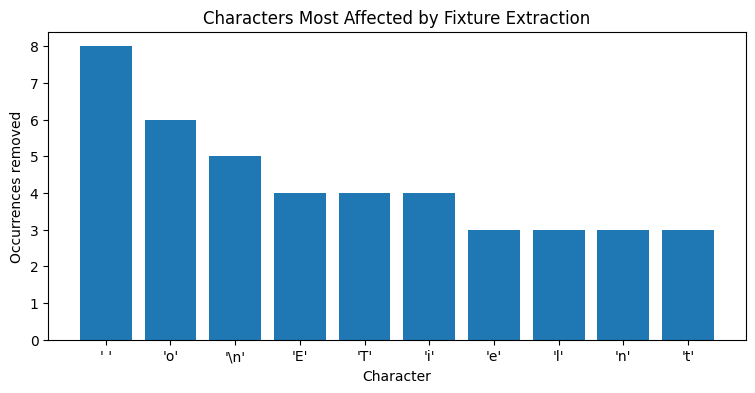

In [10]:
import matplotlib.pyplot as plt

removed_character_counts = {
    character: full_corpus_character_counts[character]
    - main_text_character_counts[character]
    for character in full_corpus_character_counts
}
most_changed_characters = sorted(
    removed_character_counts,
    key=lambda character: (-removed_character_counts[character], character),
)[:10]

plot_labels = [repr(character) for character in most_changed_characters]
plot_counts = [
    removed_character_counts[character] for character in most_changed_characters
]

plt.figure(figsize=(9, 4))
plt.bar(plot_labels, plot_counts)
plt.xlabel("Character")
plt.ylabel("Occurrences removed")
plt.title("Characters Most Affected by Fixture Extraction")
plt.show()

## Save the Prepared Text

A non-trivial preparation step should produce a stable artifact that later tokenization can reuse.
This example writes the prepared text beside the temporary fixture and verifies another UTF-8 round trip.
A real project would place an approved corpus in a documented data location outside normal notebook-generated clutter.

In [11]:
main_text_file_path = Path(temporary_directory.name) / "prepared_main_text.txt"
main_text_file_path.write_text(main_text, encoding="utf-8")
loaded_main_text = main_text_file_path.read_text(encoding="utf-8")

print("Prepared file name:", main_text_file_path.name)
print("Prepared text round trip succeeded:", loaded_main_text == main_text)

assert loaded_main_text == main_text

Prepared file name: prepared_main_text.txt
Prepared text round trip succeeded: True


## Final Checks

The last cell gathers the chapter's important invariants and then removes the temporary directory.
A failed invariant stops execution before later chapters can rely on incorrect prepared text.

In [12]:
assert loaded_corpus_text == tiny_corpus_text
assert utf8_byte_count > len(loaded_corpus_text)
assert sum(full_corpus_character_counts.values()) == len(loaded_corpus_text)
assert "TITLE:" not in main_text
assert "END OF FIXTURE" not in main_text
assert "\n\n" in main_text
assert loaded_main_text == main_text

temporary_directory_path = Path(temporary_directory.name)
temporary_directory.cleanup()
assert not temporary_directory_path.exists()

print("All corpus inspection checks passed.")
print("Temporary files were removed.")

All corpus inspection checks passed.
Temporary files were removed.


## Key Takeaways

- A corpus is text data that may span one file or many files.
- Text files contain encoded bytes, so the reader and writer must agree on an encoding.
- Boundary previews, line displays, and basic counts reveal structure before tokenization.
- Headers, footers, and metadata can alter both character frequencies and vocabulary.
- Extraction rules should be based on an inspected corpus rather than assumed to work universally.
- Prepared text should preserve intended structure and pass explicit consistency checks.
- Local fixtures keep instructional notebooks reproducible without network access or project clutter.

## Next Chapter

Chapter 6 examines text cleaning as a set of modeling decisions rather than a universal recipe.
It will compare deliberate transformations such as case normalization and whitespace handling while measuring what each transformation removes or preserves.